In [1]:
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get update -qq
!apt-get install -y -qq ./google-chrome-stable_current_amd64.deb
!pip install -q selenium


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libatk1.0-data.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../00-libatk1.0-data_2.36.0-3build1_all.deb ...
Unpacking libatk1.0-data (2.36.0-3build1) ...
Selecting previously unselected package libatk1.0-0:amd64.
Preparing to unpack .../01-libatk1.0-0_2.36.0-3build1_amd64.deb ...
Unpacking libatk1.0-0:amd64 (2.36.0-3build1) ...
Selecting previously unselected package libatspi2.0-0:amd64.
Preparing to unpack .../02-libatspi2.0-0_2.44.0-3_amd64.deb ...
Unpacking libatspi2.0-0:amd64 (2.44.0-3) ...
Selecting previously unselected package libatk-bridge2.0-0:amd64.
Preparing to unpack .../03-libatk-bridge2.0-0_2.38.0-3_amd64.deb ...
Unpacking libatk-bridge2.0-0:amd64 (2.38.0-3) ...
Selecting previously unselected pack

In [17]:
import re
import time
import pandas as pd
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException


class ProfiRuParser:

    catalog_url = "https://profi.ru/veterinar/grooming/?seamless=1&tabName=PROFILES"
    card_selector = '[class*="DesktopProfileCard"]'
    load_more_selector = 'button[data-shmid="pagination_next"]'
    price_row_selector = 'tr[data-shmid="priceRow"]'

    def __init__(self, wait_timeout: int = 15):
        self.wait_timeout = wait_timeout
        self.driver = None
        self.wait = None

    def start(self) -> None:
        options = Options()
        options.add_argument("--headless=new")
        options.add_argument("--no-sandbox")
        options.add_argument("--disable-dev-shm-usage")
        options.add_argument("--window-size=1920,1080")
        options.add_argument("--disable-blink-features=AutomationControlled")

        self.driver = webdriver.Chrome(options=options)
        self.wait = WebDriverWait(self.driver, self.wait_timeout)

    def close(self) -> None:
        if self.driver:
            self.driver.quit()
            self.driver = None

    def __enter__(self):
        self.start()
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        self.close()


    def open_catalog(self, url: str = None) -> None:
        url = url or self.catalog_url
        self.driver.get(url)
        try:
            self.wait.until(EC.presence_of_element_located(
                (By.CSS_SELECTOR, self.card_selector)
            ))
        except TimeoutException:
            self.driver.save_screenshot("profi_error.png")
            raise RuntimeError("карточки не найдены. необходимо чекнуть profi_error.png")


    def _count_cards(self) -> int:
        return len(self.driver.find_elements(
            By.CSS_SELECTOR, self.card_selector
        ))

    def load_all(self, max_clicks: int = 100) -> int:
        for click in range(1, max_clicks + 1):
            try:
                button = self.wait.until(EC.element_to_be_clickable(
                    (By.CSS_SELECTOR, self.load_more_selector)
                ))
            except TimeoutException:
                print(f"кнопка пропала - все анкеты загружены"
                      f"({self._count_cards()} шт)")
                break

            cards_before = self._count_cards()
            self.driver.execute_script("arguments[0].click();", button)

            try:
                self.wait.until(
                    lambda f: self._count_cards() > cards_before
                )
            except TimeoutException:
                print("новые карточки не появились, стоп")
                break

        else:
            print(f"достигнут лимит кликов")

        return self._count_cards()

    @staticmethod
    def _parse_price_row(row) -> dict:
        name_tag = row.select_one("td a")
        service = None
        if name_tag:
            service = re.sub(r"\s+", " ", name_tag.get_text()).strip()
        price_tag = row.select_one('p[class*="price-caption"]')
        price_text = price_tag.get_text(" ", strip=True) if price_tag else ""

        raw_numbers = re.findall(r"\d[\d\s\u00a0]*", price_text)
        numbers = [int(re.sub(r"\D", "", n)) for n in raw_numbers if n.strip()]

        if len(numbers) >= 2:
            price_min, price_max = numbers[0], numbers[1]
        elif len(numbers) == 1:
            price_min = price_max = numbers[0]
        else:
            price_min = price_max = None
        return {
            "service": service,
            "price_min": price_min,
            "price_max": price_max,
        }

    def _parse_card(self, card) -> list[dict]:
        rows = []
        for price_row in card.select(self.price_row_selector):
            data = self._parse_price_row(price_row)
            rows.append(data)

        return rows

    def parse(self) -> list[dict]:
        soup = BeautifulSoup(self.driver.page_source, "lxml")
        cards = soup.select(self.card_selector)
        print(f"карточек для парса: {len(cards)}")
        all_rows = []
        for card in cards:
            try:
                all_rows.extend(self._parse_card(card))
            except Exception as e:
                print(f"пропущена карточка из-за ошибки: {type(e).__name__}")
        return all_rows


    def do_all(self, url: str = None, max_clicks: int = 100) -> pd.DataFrame:
        self.open_catalog(url)
        self.load_all(max_clicks=max_clicks)
        rows = self.parse()

        df = pd.DataFrame(rows)
        if not df.empty:
            df = df[["service",
                     "price_min", "price_max"]]
        return df


with ProfiRuParser() as pr:
    df = pr.do_all()

    print(f"\nсобрано строк: {len(df)}")
    print(df.head(20))

    df.to_csv("profi_ru_groomers.csv", index=False, encoding="utf-8-sig")


новые карточки не появились, стоп
карточек для парса: 2667

собрано строк: 1719
                      service  price_min  price_max
0        Вычёсывание колтунов     1200.0     1200.0
1               Груминг кошек     3500.0     4000.0
2   Чистка параанальных желёз      900.0      900.0
3        Вычёсывание колтунов     1200.0     1200.0
4               Груминг кошек     3500.0     4000.0
5   Чистка параанальных желёз      900.0      900.0
6        Вычёсывание колтунов     1200.0     1200.0
7               Груминг кошек     3500.0     4000.0
8   Чистка параанальных желёз      900.0      900.0
9                     Груминг     2500.0     3500.0
10              Стрижка собак     2500.0     3500.0
11             Стрижка когтей      400.0      500.0
12                    Груминг     2500.0     3500.0
13              Стрижка собак     2500.0     3500.0
14             Стрижка когтей      400.0      500.0
15                    Груминг     2500.0     3500.0
16              Стрижка собак     25

In [18]:
df['price'] = (df['price_min'] + df['price_max'])/2
df1 = df.drop(columns=['price_min', 'price_max'])
df1 = df1.dropna()
df1

,service,price
0,Вычёсывание колтунов,1200.0
1,Груминг кошек,3750.0
2,Чистка параанальных желёз,900.0
3,Вычёсывание колтунов,1200.0
4,Груминг кошек,3750.0
...,...,...
1714,Стрижка когтей,1250.0
1715,Чистка ушей,500.0
1716,Стрижка собак,4000.0
1717,Стрижка когтей,1250.0


In [23]:
all_serv = df1['service'].unique()
#print(all_serv)
for serv in all_serv:
    avr = df[df['service'] == serv]['price'].mean()
    med = df[df['service'] == serv]['price'].median()
    print(f'услуга - {serv}')
    print(f'количество таких услуг - {len(df[df['service'] == serv])}')
    print(f'средняя стоимость - {avr}')
    print(f'медианнная стоимость - {med}')
    print('---------------')



услуга - Вычёсывание колтунов
количество таких услуг - 159
средняя стоимость - 1032.051282051282
медианная стоимость - 500.0
---------------
услуга - Груминг кошек
количество таких услуг - 150
средняя стоимость - 2844.7368421052633
медианная стоимость - 2625.0
---------------
услуга - Чистка параанальных желёз
количество таких услуг - 9
средняя стоимость - 650.0
медианная стоимость - 650.0
---------------
услуга - Груминг
количество таких услуг - 246
средняя стоимость - 2913.135593220339
медианная стоимость - 2500.0
---------------
услуга - Стрижка собак
количество таких услуг - 165
средняя стоимость - 2576.315789473684
медианная стоимость - 2500.0
---------------
услуга - Стрижка когтей
количество таких услуг - 120
средняя стоимость - 574.3055555555555
медианная стоимость - 500.0
---------------
услуга - Стрижка кошек
количество таких услуг - 156
средняя стоимость - 2509.4594594594596
медианная стоимость - 2000.0
---------------
услуга - Груминг собак
количество таких услуг - 168
сред

In [30]:
min_count = 5
counts = df1["service"].value_counts()
popular = counts[counts >= min_count].index
main_df = df1[df1["service"].isin(popular)]
main_df["service"].value_counts()

,count
service,
Груминг,177
Груминг собак,132
Вычёсывание колтунов,117
Стрижка собак,114
Груминг кошек,114
Стрижка кошек,111
Стрижка когтей,108
Мытьё животных,99
Стрижка йорка,51


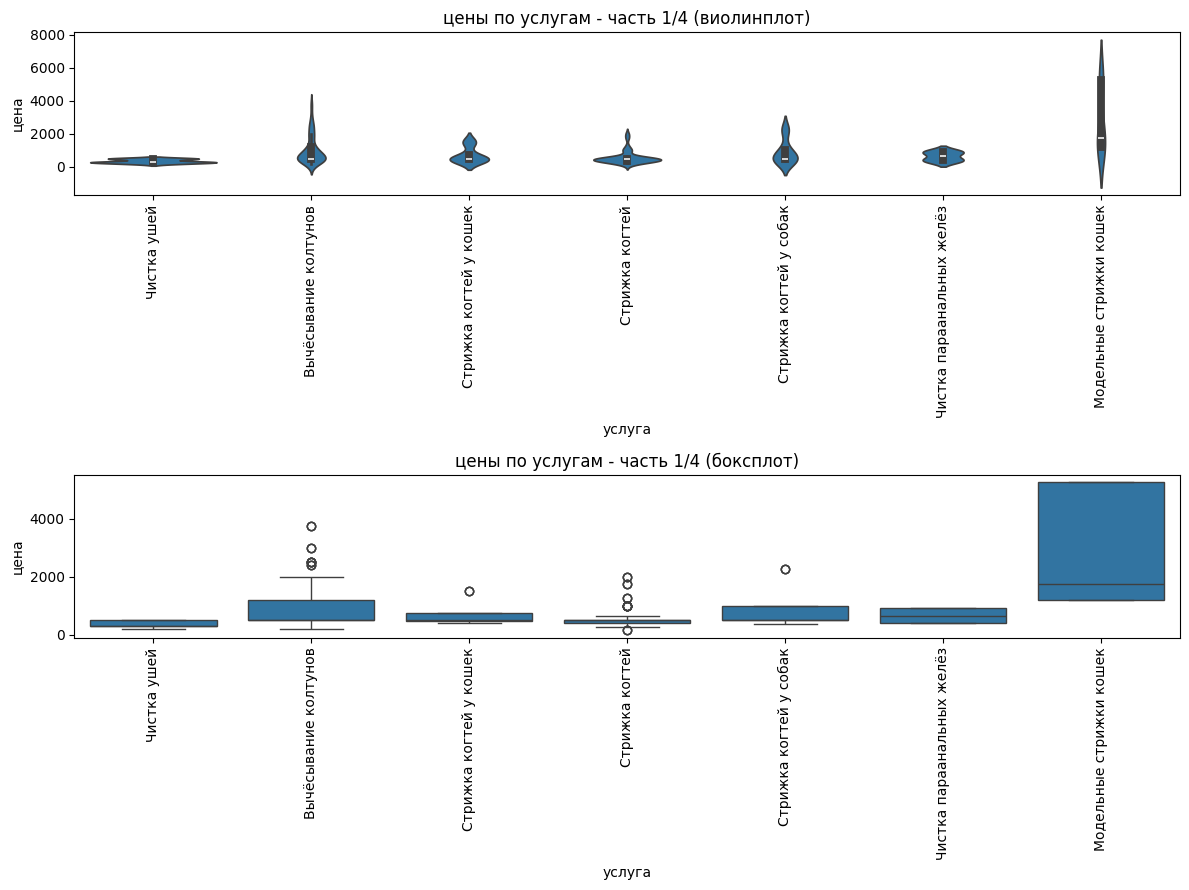

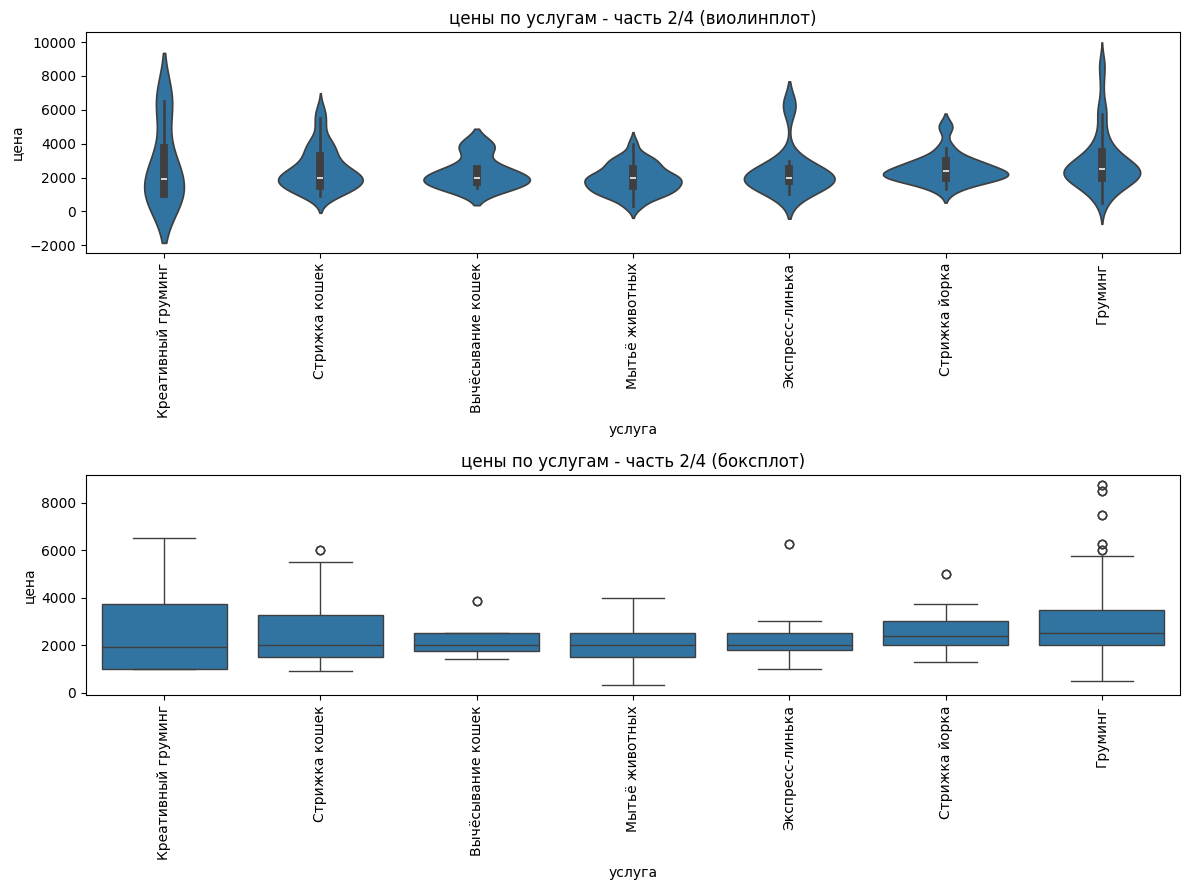

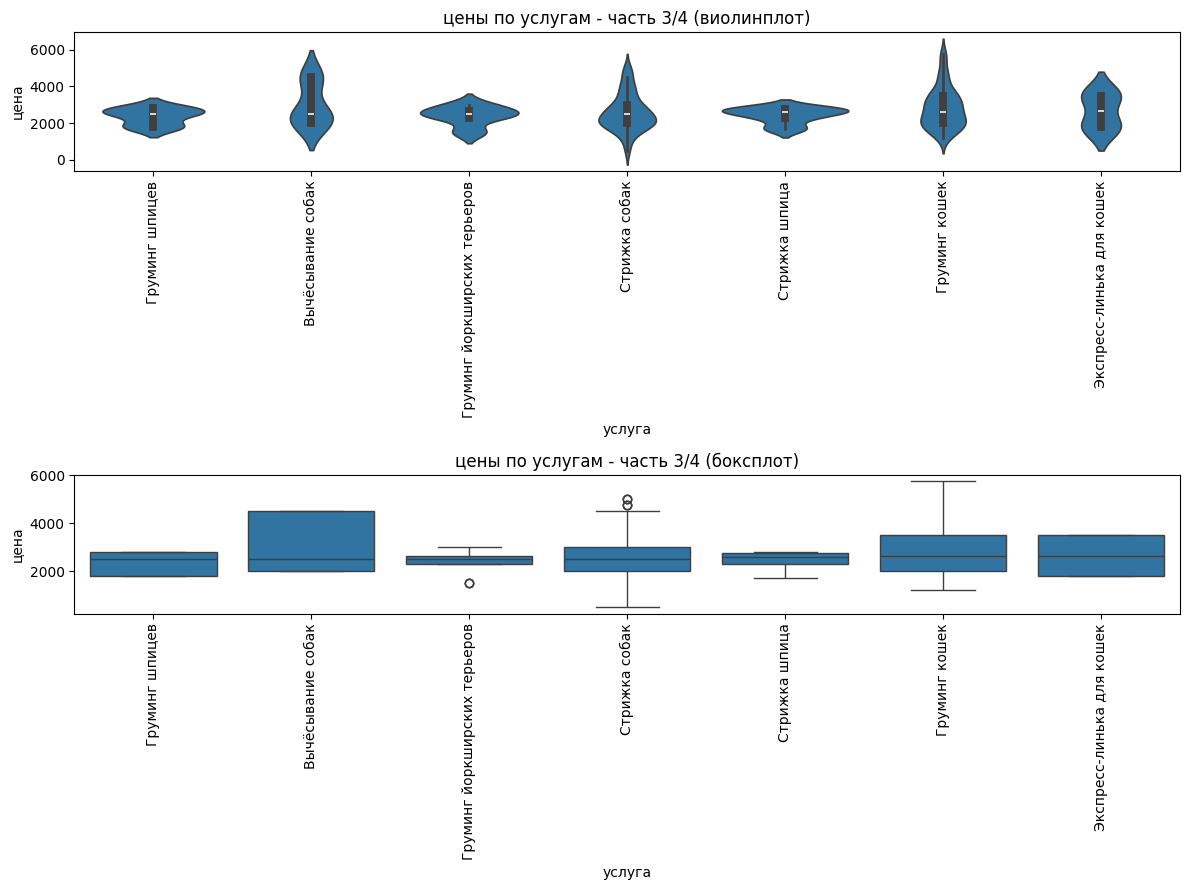

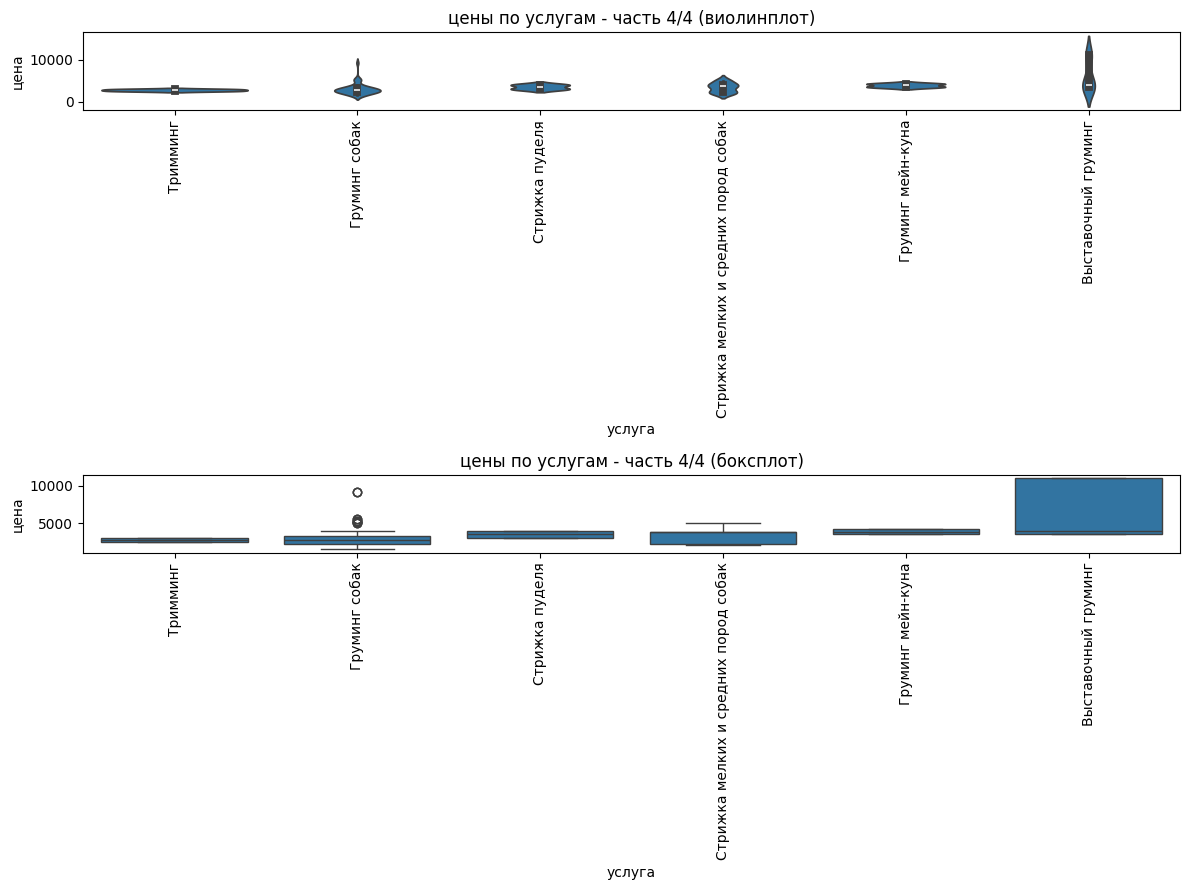

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_several(data, nparts=4):
    order = data.groupby("service")["price"].median().sort_values().index.tolist()
    parts = np.array_split(order, nparts)

    for i, part in enumerate(parts, start=1):
        subset = data[data["service"].isin(part)]
        fig, axes = plt.subplots(2, 1, figsize=(12, 9))

        sns.violinplot(data=subset, x="service", y="price",order=part, ax=axes[0])
        axes[0].set_title(f"цены по услугам - часть {i}/{nparts} (виолинплот)")
        axes[0].set_xlabel("услуга")
        axes[0].set_ylabel("цена")
        axes[0].tick_params(axis="x", rotation=90)

        sns.boxplot(data=subset, x="service", y="price",order=part, ax=axes[1])
        axes[1].set_title(f"цены по услугам - часть {i}/{nparts} (боксплот)")
        axes[1].set_xlabel("услуга")
        axes[1].set_ylabel("цена")
        axes[1].tick_params(axis="x", rotation=90)

        plt.tight_layout()
        plt.show()


plot_several(main_df, nparts=4)